<a href="https://colab.research.google.com/github/sreenathsnv/AI-ML/blob/DL/DeepLearning_pt6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Comprehensive Guide to Gradient Descent Variants**

Gradient Descent is an optimization algorithm used to minimize a cost function $J(\theta)$ by iteratively moving in the direction of steepest descent.

---

## 1. Batch Gradient Descent (BGD)
In **Batch Gradient Descent**, the gradient is calculated using the **entire dataset** for every single update.

### **The Math**
$$\theta = \theta - \eta \cdot \nabla_{\theta} J(\theta)$$
*Where $\eta$ is the learning rate.*

### **Characteristics**
* **Update Frequency:** Once per epoch (after seeing all rows).
* **Pros:** Very stable convergence; produces a smooth path to the minimum.
* **Cons:** Extremely slow on large datasets; can get stuck in local minima easily.



---

## 2. Stochastic Gradient Descent (SGD)
**SGD** updates the model parameters for **each individual training example** one by one.

### **The Math**
$$\theta = \theta - \eta \cdot \nabla_{\theta} J(\theta; x^{(i)}; y^{(i)})$$

### **Characteristics**
* **Update Frequency:** $N$ times per epoch (where $N$ is the number of rows).
* **Pros:** Much faster than BGD; the "noise" helps escape local minima.
* **Cons:** The path to the minimum is "noisy" or zig-zagged; it never truly settles at the exact minimum.



---

## 3. Mini-Batch Gradient Descent
This is the **industry standard**. It splits the data into small "batches" (e.g., 32, 64, or 128 rows) and updates parameters after each batch.

### **Why it's the gold standard:**
1. **Performance:** It uses highly optimized matrix math (Vectorization).
2. **Stability:** It is more stable than SGD but faster than BGD.

---

## 4. Modern Adaptive Optimizers
Standard Gradient Descent often struggles with "Saddle Points" or ravines. Modern deep learning uses adaptive techniques:

* **Momentum:** Adds a fraction of the previous update to the current one (like a ball gaining speed downhill).
* **RMSProp:** Scales the learning rate for each parameter based on recent gradients.
* **Adam (Adaptive Moment Estimation):** Combines Momentum and RMSProp. It is currently the most popular choice for Neural Networks.



---

### **Quick Comparison Table**

| Feature | Batch | Stochastic (SGD) | Mini-Batch |
| :--- | :--- | :--- | :--- |
| **Accuracy** | High | Low (Noisy) | Moderate/High |
| **Speed** | Slow | Fast | **Fastest (GPU)** |
| **Memory** | High (All data) | Low (1 row) | Moderate (Batch size) |

---

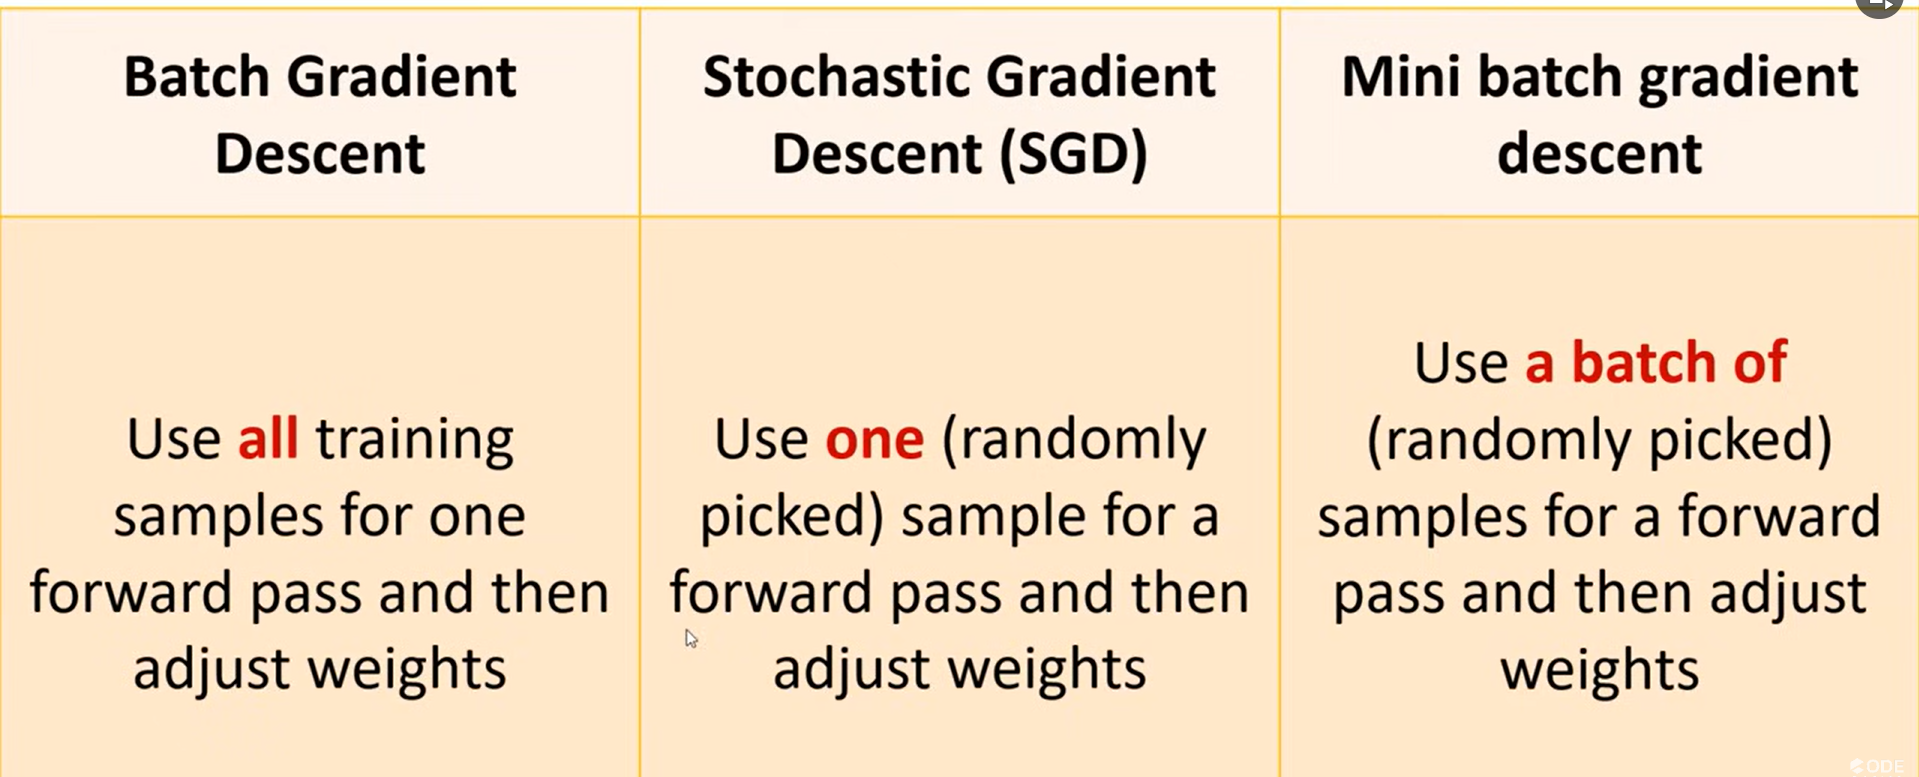

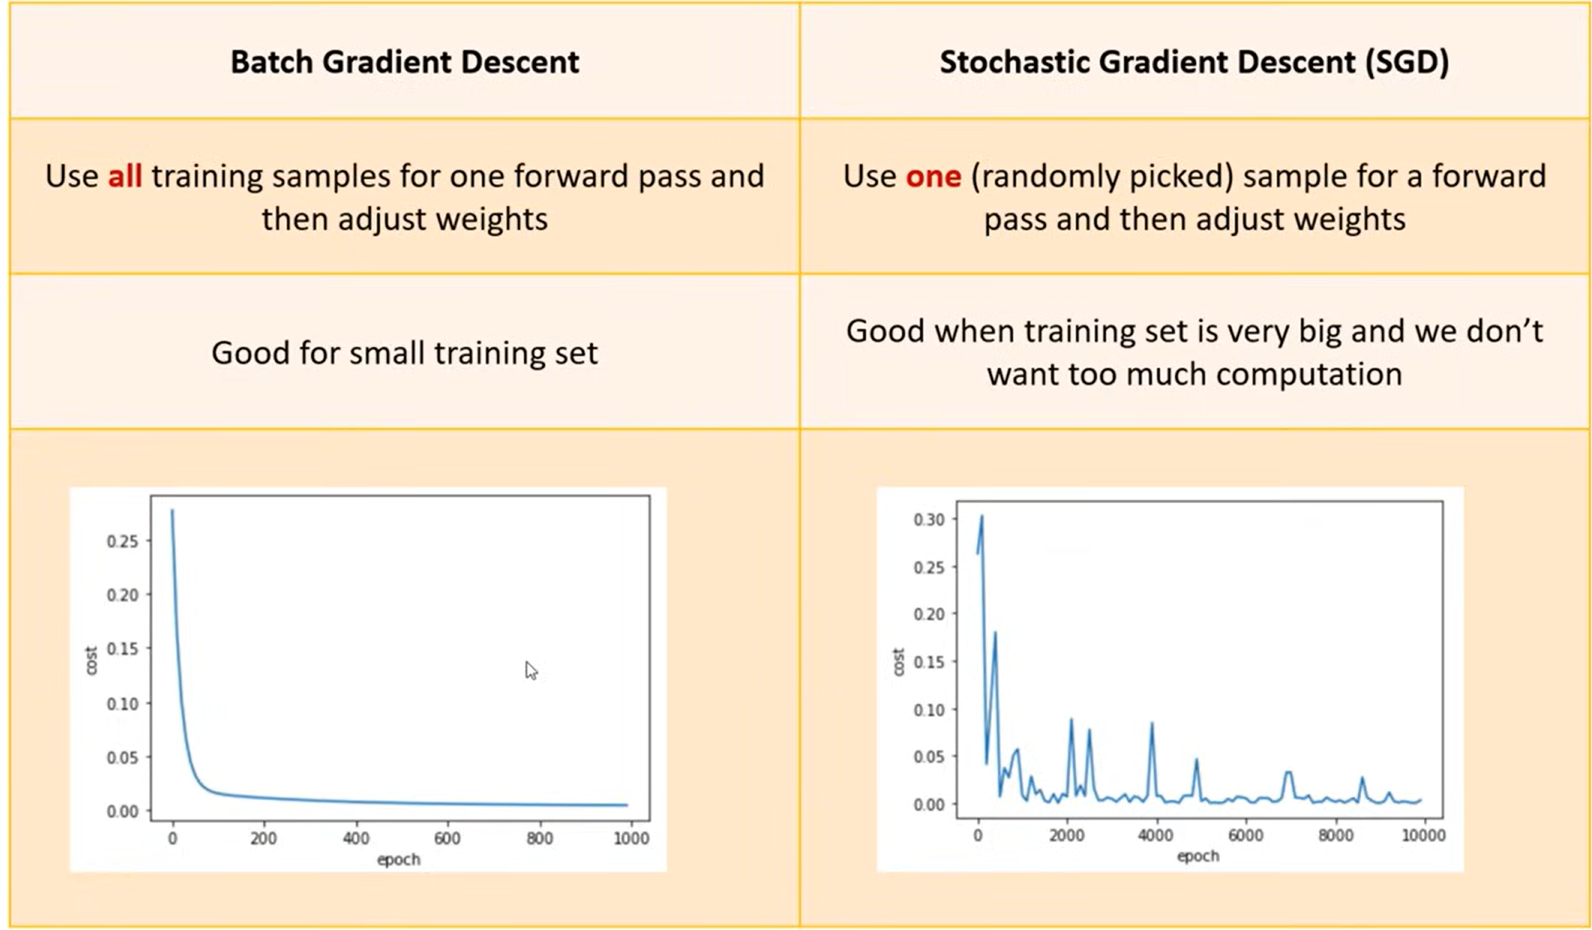

## Code Implementaion

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [83]:
data = [
    [2600, 3, 20, 550000],
    [3000, 4, 15, 565000],
    [3200, 3, 18, 610000],
    [3600, 3, 30, 595000],
    [4000, 5, 8, 760000],
    [4100, 6, 8, 810000],


    [1800, 2, 25, 350000],
    [2000, 3, 20, 420000],
    [2200, 3, 15, 480000],
    [2400, 3, 10, 500000],
    [2600, 4, 12, 540000],
    [2800, 4, 8, 600000],
    [3000, 4, 5, 650000],
    [3200, 4, 4, 700000],
    [3400, 5, 3, 730000],
    [3600, 5, 2, 780000],
    [3800, 5, 2, 820000],
    [4000, 6, 1, 880000],
    [4200, 6, 1, 920000],
    [4400, 6, 1, 970000],
    [4600, 7, 1, 1020000],
    [4800, 7, 1, 1080000],
    [5000, 7, 1, 1150000],

    [2100, 3, 18, 460000],
    [2300, 3, 14, 490000],
    [2500, 3, 10, 530000],
    [2700, 4, 9, 580000],
    [2900, 4, 7, 610000],
    [3100, 4, 6, 660000],
    [3300, 4, 5, 710000],
    [3500, 5, 4, 750000],
    [3700, 5, 3, 800000],
    [3900, 5, 2, 840000],
    [4100, 6, 2, 890000],
    [4300, 6, 2, 940000],
    [4500, 6, 2, 990000],
    [4700, 7, 2, 1050000],
    [4900, 7, 2, 1100000],

    [1950, 2, 22, 370000],
    [2150, 3, 19, 450000],
    [2350, 3, 16, 480000],
    [2550, 3, 13, 520000],
    [2750, 4, 11, 570000],
    [2950, 4, 9, 610000],
    [3150, 4, 7, 670000],
    [3350, 4, 6, 720000],
    [3550, 5, 5, 760000],
    [3750, 5, 4, 810000],
    [3950, 5, 3, 850000],
    [4150, 6, 3, 900000],
    [4350, 6, 3, 950000],
    [4550, 6, 3, 1000000],
    [4750, 7, 3, 1060000]
]

df = pd.DataFrame(data, columns=["area", "bedrooms", "age", "price"])

df.head()

,area,bedrooms,age,price
0,2600,3,20,550000
1,3000,4,15,565000
2,3200,3,18,610000
3,3600,3,30,595000
4,4000,5,8,760000


In [84]:
df.shape

(53, 4)

In [85]:
from re import X
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('price', axis=1), df['price'], test_size=0.2, random_state=42)

In [86]:
from sklearn.preprocessing import MinMaxScaler

# Scaler for features (X)
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scaler for target (y)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

In [87]:
np.ones(shape=7)

array([1., 1., 1., 1., 1., 1., 1.])

In [88]:
X_scaled.T

array([[0.125     , 0.28125   , 0.        , 0.78125   , 0.6875    ,
        0.96875   , 0.15625   , 0.421875  , 0.71875   , 0.734375  ,
        0.5625    , 0.1875    , 0.625     , 0.53125   , 0.90625   ,
        0.21875   , 0.3125    , 0.25      , 0.546875  , 0.34375   ,
        0.59375   , 0.109375  , 0.46875   , 0.484375  , 0.375     ,
        0.9375    , 0.4375    , 0.171875  , 0.84375   , 0.09375   ,
        0.671875  , 0.25      , 1.        , 0.75      , 0.921875  ,
        0.875     , 0.0625    , 0.296875  , 0.5       , 0.40625   ,
        0.859375  , 0.046875  ],
       [0.2       , 0.4       , 0.        , 0.8       , 0.6       ,
        1.        , 0.2       , 0.4       , 0.8       , 0.8       ,
        0.6       , 0.2       , 0.6       , 0.6       , 1.        ,
        0.2       , 0.4       , 0.2       , 0.6       , 0.4       ,
        0.6       , 0.2       , 0.4       , 0.4       , 0.4       ,
        1.        , 0.2       , 0.2       , 0.8       , 0.2       ,
        0.6    

In [89]:
X_scaled.shape

(42, 3)

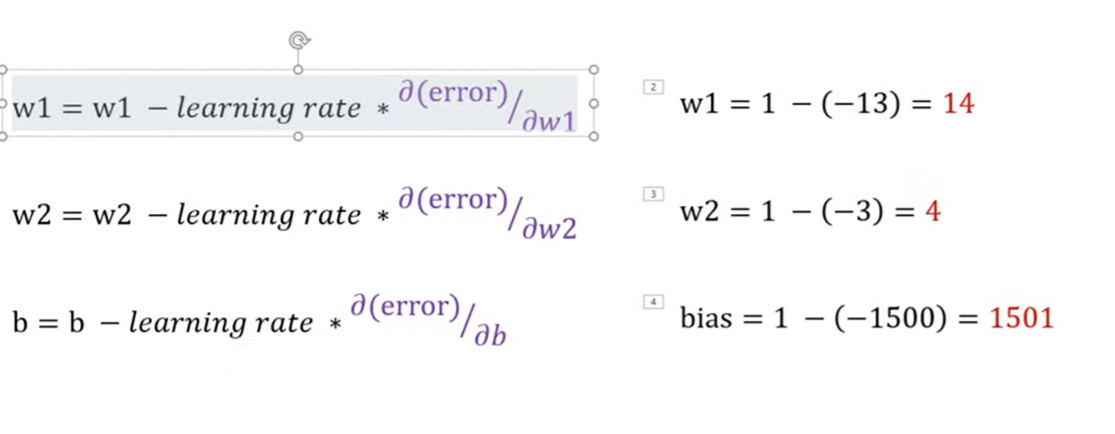

In [90]:
y_scaled

array([[0.1625 ],
       [0.2875 ],
       [0.     ],
       [0.7375 ],
       [0.5125 ],
       [0.9375 ],
       [0.175  ],
       [0.4    ],
       [0.675  ],
       [0.6875 ],
       [0.5375 ],
       [0.1875 ],
       [0.5875 ],
       [0.5    ],
       [0.875  ],
       [0.225  ],
       [0.3125 ],
       [0.25   ],
       [0.5125 ],
       [0.325  ],
       [0.5625 ],
       [0.125  ],
       [0.45   ],
       [0.4625 ],
       [0.26875],
       [0.9125 ],
       [0.325  ],
       [0.1625 ],
       [0.8    ],
       [0.1375 ],
       [0.625  ],
       [0.2375 ],
       [1.     ],
       [0.7125 ],
       [0.8875 ],
       [0.8375 ],
       [0.0875 ],
       [0.275  ],
       [0.475  ],
       [0.3875 ],
       [0.8125 ],
       [0.025  ]])

In [91]:
number_of_features = X_scaled.shape[1]
w = np.ones(shape=number_of_features)
w

array([1., 1., 1.])

In [92]:
def gradient_descent(X,y,epochs,learning_rate):


  number_of_features = X.shape[1] # 3

  w = np.ones(shape=number_of_features).reshape(number_of_features,1) # (3, 1)

  bias = 0

  total_samples = X.shape[0] # 53

  epoch = []
  cost = []

  for i in range(epochs):
    weighted_sum = np.dot(X, w) + bias # (53,3) . (3,1) => (53,1)

    error = weighted_sum - y # (53,1) - (53,1) => (53,1)
    w_grad = 2/total_samples * np.dot(X.T, error) # (3, 53) . (53, 1) => (3, 1)
    b_grad = 2/total_samples * np.sum(error)

    w = w - learning_rate * w_grad
    bias = bias - learning_rate * b_grad

    print(f'w = {w.T},bias= {bias} , epoch={i}') # Print w.T for compact output



    epoch.append(i)
    cost.append(np.mean(np.square(error))) # Use the calculated error directly

  return w,bias , cost , epoch

In [93]:
w,bias , cost , epoch = gradient_descent(X_scaled,y_scaled,1000,0.05)

w = [[0.95727597 0.95502728 0.97406136]],bias= -0.08410962301587302 , epoch=0
w = [[0.92173812 0.91759557 0.95180288]],bias= -0.1546261958292292 , epoch=1
w = [[0.89221079 0.88647143 0.93263422]],bias= -0.21375885687681578 , epoch=2
w = [[0.86770983 0.86062235 0.91606097]],bias= -0.26335716560885913 , epoch=3
w = [[0.84741146 0.83918402 0.90166904]],bias= -0.30496964234730284 , epoch=4
w = [[0.8306261  0.82143298 0.88911159]],bias= -0.3398927775523208 , epoch=5
w = [[0.81677656 0.80676366 0.87809808]],bias= -0.36921206213160945 , epoch=6
w = [[0.80537974 0.79466918 0.86838509]],bias= -0.3938363378119465 , epoch=7
w = [[0.79603127 0.78472529 0.8597687 ]],bias= -0.41452655510466535 , epoch=8
w = [[0.78839275 0.77657692 0.85207801]],bias= -0.4319198493402955 , epoch=9
w = [[0.78218096 0.76992691 0.84516979]],bias= -0.4465496970170187 , epoch=10
w = [[0.77715889 0.76452658 0.83892399]],bias= -0.4588627906097869 , epoch=11
w = [[0.7731282  0.76016783 0.83323994]],bias= -0.4692331660929802 ,

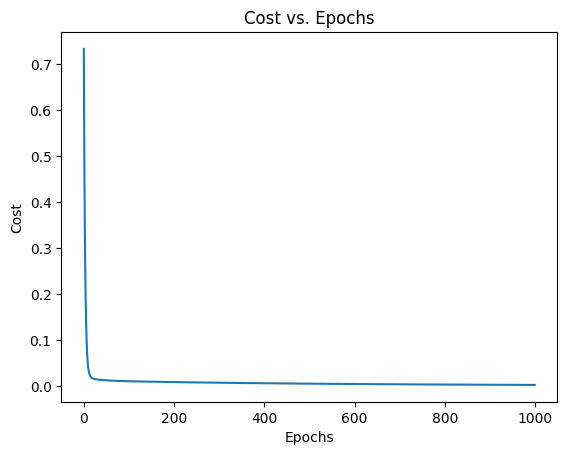

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.plot(epoch,cost)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Cost vs. Epochs')
plt.show()

In [112]:
def batch_gradient_descent(X,y,epoch=1000,lr=0.05):
  number_of_features = X.shape[1]

  w = np.ones(shape=number_of_features).reshape(number_of_features,1)
  b = 0
  total_samples = X.shape[0]
  costs= []
  epochs = []
  for i in range(epoch):

    weighted_sum = np.dot(X,w) + b
    error = weighted_sum - y

    w_grad = 2/total_samples * np.dot(X.T,error)
    b_grad = 2/total_samples * np.sum(error)

    w = w - lr * w_grad
    b = b - lr * b_grad
    mse =  np.mean(np.square(error))

    if i%10 == 0:

      print(f'w = {w.T},bias= {b} , epoch={i} , cost = {mse}')
      epochs.append(i)
      costs.append(mse)

  return w,b,costs,epochs

In [113]:
w,bias , cost , epoch = batch_gradient_descent(X_scaled,y_scaled,2000,0.05)

w = [[0.95727597 0.95502728 0.97406136]],bias= -0.08410962301587302 , epoch=0 , cost = 0.7325396567046958
w = [[0.78218096 0.76992691 0.84516979]],bias= -0.4465496970170187 , epoch=10 , cost = 0.038587731134990574
w = [[0.76137828 0.74685015 0.80022871]],bias= -0.5109789242127376 , epoch=20 , cost = 0.016576810705434313
w = [[0.76457411 0.74907423 0.77275572]],bias= -0.5235777746411462 , epoch=30 , cost = 0.014454017090964359
w = [[0.77012762 0.75387128 0.75090482]],bias= -0.526261051104615 , epoch=40 , cost = 0.013340162024229432
w = [[0.7747018  0.75772075 0.73218379]],bias= -0.526341413253519 , epoch=50 , cost = 0.012547242595592301
w = [[0.7779951  0.76029031 0.71577381]],bias= -0.5252369313584667 , epoch=60 , cost = 0.011957817623782478
w = [[0.78017019 0.76173768 0.7012133 ]],bias= -0.52333467206116 , epoch=70 , cost = 0.011503887639656549
w = [[0.78142828 0.76226341 0.68816142]],bias= -0.5208197060766917 , epoch=80 , cost = 0.011140758074636988
w = [[0.78194454 0.76204274 0.6763

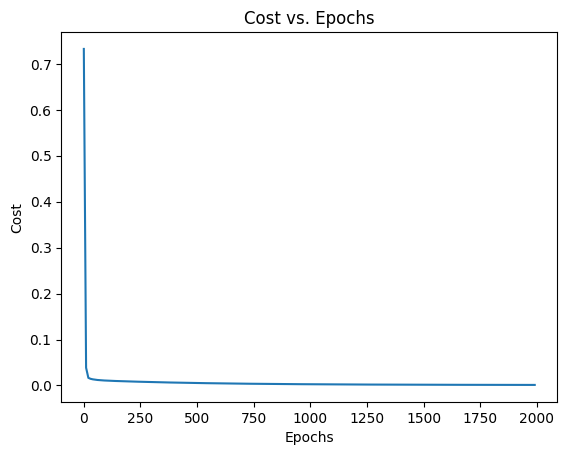

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.plot(epoch,cost)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Cost vs. Epochs')
plt.show()

In [115]:
def predict(X):


  # Perform prediction using scaled features
  y_pred_scaled = np.dot(X, w) + bias

  # Inverse transform the predicted values using scaler_y
  return scaler_y.inverse_transform(y_pred_scaled)


# Example usage with X_test to get predictions on the test set
predictions_on_test = predict(X_test_scaled)
print(predictions_on_test[0]) # Print the first prediction

[952867.31407569]


In [99]:
y_test.iloc[0]

np.int64(970000)

In [144]:
def stochastic_gradient_descent(X,y,epochs=1000,lr=0.05):

  no_of_features = X.shape[1]
  total_samples = X.shape[0]

  w = np.ones(shape=no_of_features).reshape(no_of_features,1)
  b  = 0

  costs = []
  epoch = []

  for i in range(epochs+1):

    random_index = np.random.randint(0,total_samples)
    sample_x = X[random_index]
    sample_y = X[random_index]

    weighted_sum = np.dot(sample_x,w) + b
    error = weighted_sum - sample_y

    w_grad = 2/total_samples * np.dot(sample_x.T,error)
    b_grad = 2/total_samples * np.sum(error)

    w = w - lr * w_grad
    b = b - lr * b_grad

    mse =  np.mean(np.square(error))

    if i%1000 == 0:

      print(f'w = {w.T},bias= {b} , epoch={i} , cost = {mse}')
      epoch.append(i)
      costs.append(mse)

  return w,b,costs,epoch





In [157]:
w,bias , cost , epoch = stochastic_gradient_descent(X_scaled,y_scaled,100000,0.0001)

w = [[0.99999784 0.99999784 0.99999784]],bias= -9.543650793650794e-06 , epoch=0 , cost = 0.5182320601851853
w = [[0.99536359 0.99536359 0.99536359]],bias= -0.01233304964321312 , epoch=1000 , cost = 0.5281641128710833
w = [[0.99087674 0.99087674 0.99087674]],bias= -0.024302644713709156 , epoch=2000 , cost = 1.8884406997599408
w = [[0.98652771 0.98652771 0.98652771]],bias= -0.036039888672742604 , epoch=3000 , cost = 0.3327209049748155
w = [[0.98215673 0.98215673 0.98215673]],bias= -0.0477062804290298 , epoch=4000 , cost = 1.135347936682393
w = [[0.97800886 0.97800886 0.97800886]],bias= -0.05890606598119974 , epoch=5000 , cost = 0.21119402580114677
w = [[0.97400498 0.97400498 0.97400498]],bias= -0.06992681972252922 , epoch=6000 , cost = 0.7060581555215238
w = [[0.97002933 0.97002933 0.97002933]],bias= -0.08069136535207352 , epoch=7000 , cost = 0.6235521981312476
w = [[0.96610074 0.96610074 0.96610074]],bias= -0.09134588307572993 , epoch=8000 , cost = 1.3972081634802682
w = [[0.96234413 0.

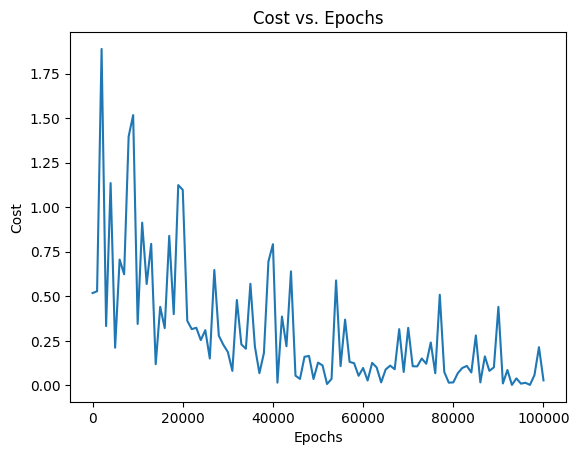

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.plot(epoch,cost)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Cost vs. Epochs')
plt.show()

In [159]:
predict(X_test_scaled)[0]

array([1013618.82155803])

#### Note

for SGD, we need to use smaller lr value since SGD is so jumpy, a high learning rate keeps "kicking" the model away from the minimum

In [178]:
def min_batch_gradient_descent(X,y,epochs=1000,lr=0.05,batch_size=10):

  no_of_features = X.shape[1]
  total_samples = X.shape[0]

  w = np.ones(shape=no_of_features).reshape(no_of_features,1)
  b  = 0

  costs = []
  epoch = []

  for i in range(epochs+1):

    random_index_m = np.random.randint(0,total_samples/2)
    index_n = random_index_m + batch_size
    sample_x = X[random_index_m:index_n+1]
    sample_y = X[random_index_m:index_n+1]

    weighted_sum = np.dot(sample_x,w) + b
    error = weighted_sum - sample_y

    w_grad = 2/total_samples * np.dot(sample_x.T,error)
    b_grad = 2/total_samples * np.sum(error)

    w = w - lr * w_grad
    b = b - lr * b_grad

    mse =  np.mean(np.square(error))

    if i%1000 == 0:

      print(f'w = {w.T},bias= {b} , epoch={i} , cost = {mse}')
      epoch.append(i)
      costs.append(mse)

  return w,b,costs,epoch





In [179]:
w,bias , cost , epoch = min_batch_gradient_descent(X_scaled,y_scaled,100000,0.0001,16)

w = [[0.99996926 0.99996742 0.99998317]
 [0.99997042 0.99996888 0.99998355]
 [0.99995266 0.99995003 0.99998665]],bias= -0.00020154761904761905 , epoch=0 , cost = 0.7936742578976037
w = [[0.97268843 0.97153416 0.98304025]
 [0.9733303  0.97264304 0.98321128]
 [0.95582692 0.95420126 0.98861286]],bias= -0.17875673087607954 , epoch=1000 , cost = 0.5128749231791246
w = [[0.95265851 0.95063265 0.97018814]
 [0.95388164 0.95279026 0.97050859]
 [0.91967719 0.91674777 0.98151527]],bias= -0.3120989300618537 , epoch=2000 , cost = 0.26948142561665706
w = [[0.93812594 0.93539366 0.96060148]
 [0.93995443 0.9386076  0.96107244]
 [0.88970288 0.88561488 0.97774587]],bias= -0.41101453143644173 , epoch=3000 , cost = 0.21552287856973182
w = [[0.9276021  0.9243271  0.95323464]
 [0.92995858 0.92852558 0.95382953]
 [0.86450264 0.85946772 0.97634372]],bias= -0.48465992935766683 , epoch=4000 , cost = 0.1372712373889569
w = [[0.92000964 0.9163037  0.94754577]
 [0.92283973 0.92143624 0.94824286]
 [0.84279155 0.836

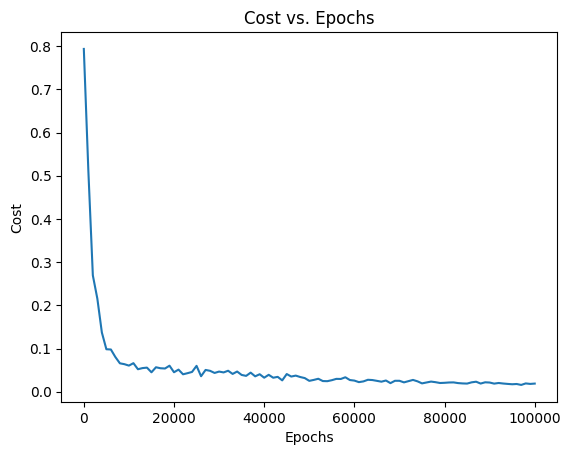

In [180]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.plot(epoch,cost)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Cost vs. Epochs')
plt.show()

In [174]:
predict(X_test_scaled)[0]

array([ 986332.89025341, 1009322.41288099,  447021.75377991])